In [20]:
import os
from matplotlib.colors import to_hex
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

if os.path.split(os.getcwd())[1] == 'Visualization':
    os.chdir('../..')

result_file_names = ['pam_parametrizer_statistics_2024-06-14.xlsx']
PAM_DATA_FILE_PATH = os.path.join('Data', 'proteinAllocationModel_iML1515_EnzymaticData_230503.xls')

max_iteration = 10

## 1. Get the data
### 1.1 Get the original kcat values

In [10]:
original_kcat_df = pd.read_excel(PAM_DATA_FILE_PATH, sheet_name='ActiveEnzymes', ignore_index = True)
original_kcat_df

,Unnamed: 0,rxnID,kegg_id,Reactants,Products,GPR,kegg_b,molMass,EC_nmbr,direction,kcat
0,0,CYTDK2,R00517,"['C00475', 'C00044']","['C00055', 'C00035', 'C00080']",b2066,['b2066'],24353.0000,4.2.1.17,b,162.9332
1,1,CYTDK2,R00517,"['C00475', 'C00044']","['C00055', 'C00035', 'C00080']",b2066,['b2066'],24353.0000,4.2.1.17,f,150.7242
2,2,XPPT,R02142,"['C00119', 'C00385']","['C00013', 'C00655']",b0238,['b0125'],20115.0000,1.2.4.1,f,0.7091
3,3,XPPT,R02142,"['C00119', 'C00385']","['C00013', 'C00655']",b0238,['b0125'],20115.0000,2.2.1.6,b,3.5093
4,4,XPPT,R02142,"['C00119', 'C00385']","['C00013', 'C00655']",b0238,['b0125'],20115.0000,2.2.1.6,f,0.9495
...,...,...,...,...,...,...,...,...,...,...,...
4388,1940,MPTS,NaN,NaN,NaN,b0785 and b0784,[],39959.4825,NaN,f,11.0000
4389,1941,MOCOS,NaN,"['C00080', 'C06232', 'C19848']",NaN,b0827,[],39959.4825,NaN,f,11.0000
4390,1942,BMOGDS2,NaN,NaN,NaN,(b3857 and b3856) or b3857,[],39959.4825,NaN,f,11.0000
4391,1943,FESD2s,NaN,NaN,NaN,s0001,[],39959.4825,NaN,f,11.0000


### 1.2. Get the altered kcat values

In [52]:
file = result_file_names[0]
best_indiv_all_rounds = pd.read_excel(os.path.join('Results', file), sheet_name='Best_Individuals',  ignore_index = True)#.drop_duplicates(
    #['iteration', 'run_id', 'kcat[s-1]', 'rxn_id', 'enzyme_id', 'direction']).reset_index()

best_indiv_all_rounds = best_indiv_all_rounds.drop_duplicates(
        subset=['enzyme_id', 'rxn_id', 'r_squared', 'direction'], keep='first').reset_index()

best_indiv_all_rounds

,index,iteration,binned,run_id,enzyme_id,rxn_id,kcat[s-1],ga_error,r_squared,direction
0,0,1,False,1,2.8.3.9,ENO,23.208296,0.256433,0.130208,f
1,1,1,False,1,3.1.3.97,GAPD,54.046449,0.256433,0.130208,f
2,2,1,False,1,3.5.4.3,ASPK,223.850395,0.256433,0.130208,f
3,3,1,False,1,E436,CYTBO3_4pp,15.554025,0.256433,0.130208,f
4,4,1,False,2,2.3.3.9,FUM,75.915203,0.305979,0.815029,f
...,...,...,...,...,...,...,...,...,...,...
522,1073,10,False,3,2.7.2.2,AP4AH,1784.557952,-1.025389,0.990475,f
523,1083,10,False,3,3.4.11.23,LEUTAi,512.599701,-1.025389,0.990475,f
524,1092,10,False,3,4.2.1.17,AMANAPEr,8.896490,-1.025389,0.983968,f
525,1093,10,False,3,4.2.1.17,AMANAPEr,8.896490,-1.025389,0.990475,f


## 2. Calculate the relative change in kcat
### 2.1 Match the original kcats

In [124]:
# Group by enzyme and calculate the relative absolute change in kcat
def calculate_relative_change(group):
    previous_kcat = get_previous_kcat_values(group)        
    
    group['previous_kcat'] = previous_kcat
    group['kcat_change'] = group['kcat[s-1]'] - previous_kcat#.abs()
    
    group['relative_change'] = group['kcat_change'] / previous_kcat#.abs()
    return group

def get_previous_kcat_values(group):
    previous_kcat = group['kcat[s-1]'].shift(1)
    #if there is no previous kcat change, get it from original kcat dataset
    for i in group.index:
        if pd.isna(previous_kcat.loc[i]):
            entry = group.loc[i]
            if not entry['enzyme_id'].startswith('E'): 
                original_kcat_value = original_kcat_df[
                    (original_kcat_df['rxnID'] == entry['rxn_id']) & 
                    (original_kcat_df['EC_nmbr'] == entry['enzyme_id'])
                ]['kcat'].values[0]
            else:
                #these are fictional enzymes and cannot be used to find enzyme/rxn combinations
                original_kcat_value = original_kcat_df[
                    (original_kcat_df['rxnID'] == entry['rxn_id'])
                ]['kcat'].values[0]
            previous_kcat.loc[i] = original_kcat_value
    return previous_kcat

def calculate_kcat_differences(group):
    group_sorted = group.sort_values('run_id')

    group_sorted = group_sorted.groupby(
        'enzyme_id',group_keys=False).apply(calculate_relative_change).reset_index(drop=True)
    return group_sorted
        

In [85]:
# Ensure the dataframe is sorted by enzyme and run
best_indiv_all_rounds_diff_kcat = best_indiv_all_rounds.groupby(
    'iteration').apply(calculate_kcat_differences).reset_index(drop=True).drop_duplicates(
    ['iteration', 'run_id', 'kcat[s-1]', 'rxn_id', 'enzyme_id', 'direction']).reset_index()
best_indiv_all_rounds_diff_kcat

,level_0,index,iteration,binned,run_id,enzyme_id,rxn_id,kcat[s-1],ga_error,r_squared,direction,previous_kcat,kcat_change,relative_change
0,0,0,1,False,1,2.8.3.9,ENO,23.208296,0.256433,0.130208,f,11.968900,11.239396,0.939050
1,1,1,1,False,1,3.1.3.97,GAPD,54.046449,0.256433,0.130208,f,18.781900,35.264549,1.877582
2,2,2,1,False,1,3.5.4.3,ASPK,223.850395,0.256433,0.130208,f,0.232600,223.617795,961.383471
3,3,3,1,False,1,E436,CYTBO3_4pp,15.554025,0.256433,0.130208,f,11.000000,4.554025,0.414002
4,4,4,1,False,2,2.3.3.9,FUM,75.915203,0.305979,0.815029,f,139.841200,-63.925997,-0.457133
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259,520,1063,10,False,2,E53,O2tpp,204.165543,0.377260,0.598890,f,11.000000,193.165543,17.560504
260,521,1072,10,False,3,2.7.2.2,AP4AH,1784.557952,-1.025389,0.983968,f,4.820217,1779.737734,369.223550
261,523,1083,10,False,3,3.4.11.23,LEUTAi,512.599701,-1.025389,0.990475,f,0.561400,512.038301,912.073923
262,524,1092,10,False,3,4.2.1.17,AMANAPEr,8.896490,-1.025389,0.983968,f,31.223300,-22.326810,-0.715069


## 3. Plot the results

### 3.1 Overview plot of all enzymes, runs and iterations

In [67]:
cmap = plt.get_cmap('viridis')

best_indiv_grouped = best_indiv_all_rounds_diff_kcat.groupby('iteration')
all_enzymes = best_indiv_all_rounds_diff_kcat.enzyme_id.unique()
enzyme_to_color = {enz:to_hex(cmap(i / (len(all_enzymes) + 1))) for i, enz in enumerate(all_enzymes)}

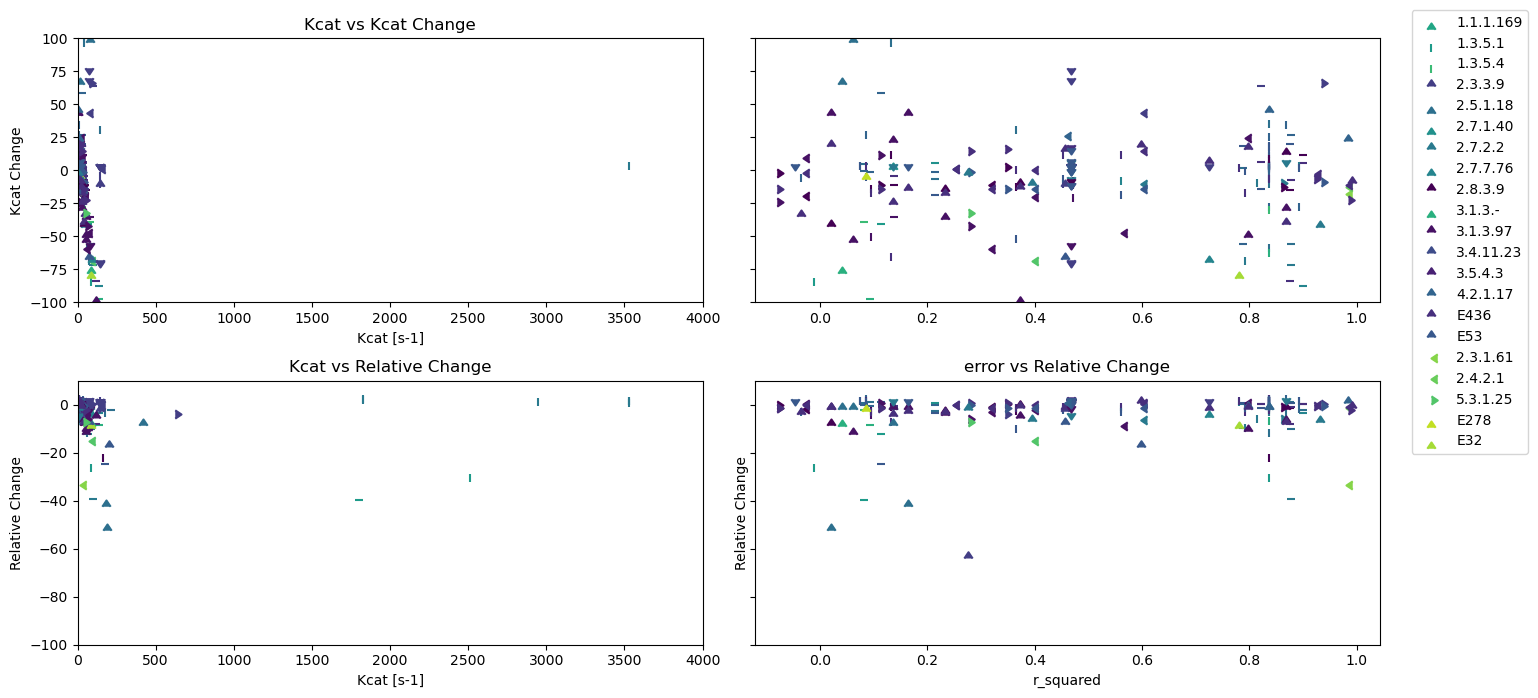

In [86]:
config = best_indiv_all_rounds_diff_kcat.iloc[0]['binned']

fig, axs = plt.subplots(ncols=len(result_file_names)+1,nrows = 2, sharey='row',figsize=(14, 7), dpi=100)
for iteration, best_indiv_df in best_indiv_grouped:
    row_index = 0
    for enzyme_id, enzyme_data in best_indiv_df.groupby('enzyme_id'):
        color = enzyme_to_color[enzyme_id]
        
        # Plot for kcat_change
        axs[row_index, 0].scatter(enzyme_data['kcat[s-1]'], enzyme_data['kcat_change'], 
                                  color=color, marker=iteration, label=f'{enzyme_id}')
        axs[row_index, 1].scatter(enzyme_data['r_squared'], enzyme_data['kcat_change'], 
                                  color=color, marker=iteration, label=f'{enzyme_id}')
        
        # Plot for relative_change
        axs[row_index + 1, 0].scatter(enzyme_data['kcat[s-1]'], enzyme_data['relative_change'], 
                                      color=color, marker=iteration, label=f'{enzyme_id}')
        
        # Plot for relative_change
        axs[row_index + 1, 1].scatter(enzyme_data['r_squared'], enzyme_data['relative_change'], 
                                      color=color, marker=iteration, label=f'{enzyme_id}')

# Set titles and labels
axs[0, 0].set_title('Kcat vs Kcat Change')
axs[0, 0].set_xlabel('Kcat [s-1]')
axs[0, 0].set_ylabel('Kcat Change')
axs[0, 0].set_ylim([-100,100])
axs[0, 0].set_xlim([0,4000])

axs[1, 0].set_title('Kcat vs Relative Change')
axs[1, 0].set_xlabel('Kcat [s-1]')
axs[1, 0].set_ylabel('Relative Change')
axs[1, 1].set_title('error vs Relative Change')
axs[1, 1].set_xlabel('r_squared')
axs[1, 1].set_ylabel('Relative Change')

axs[1, 0].set_ylim([-100,10])
axs[1, 0].set_xlim([0,4000])

# Create legends
handles, labels = axs[1, 0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(), loc='upper right', bbox_to_anchor=(1.1, 1))

plt.tight_layout()
plt.show()



### 3.2 Overview as lineplot

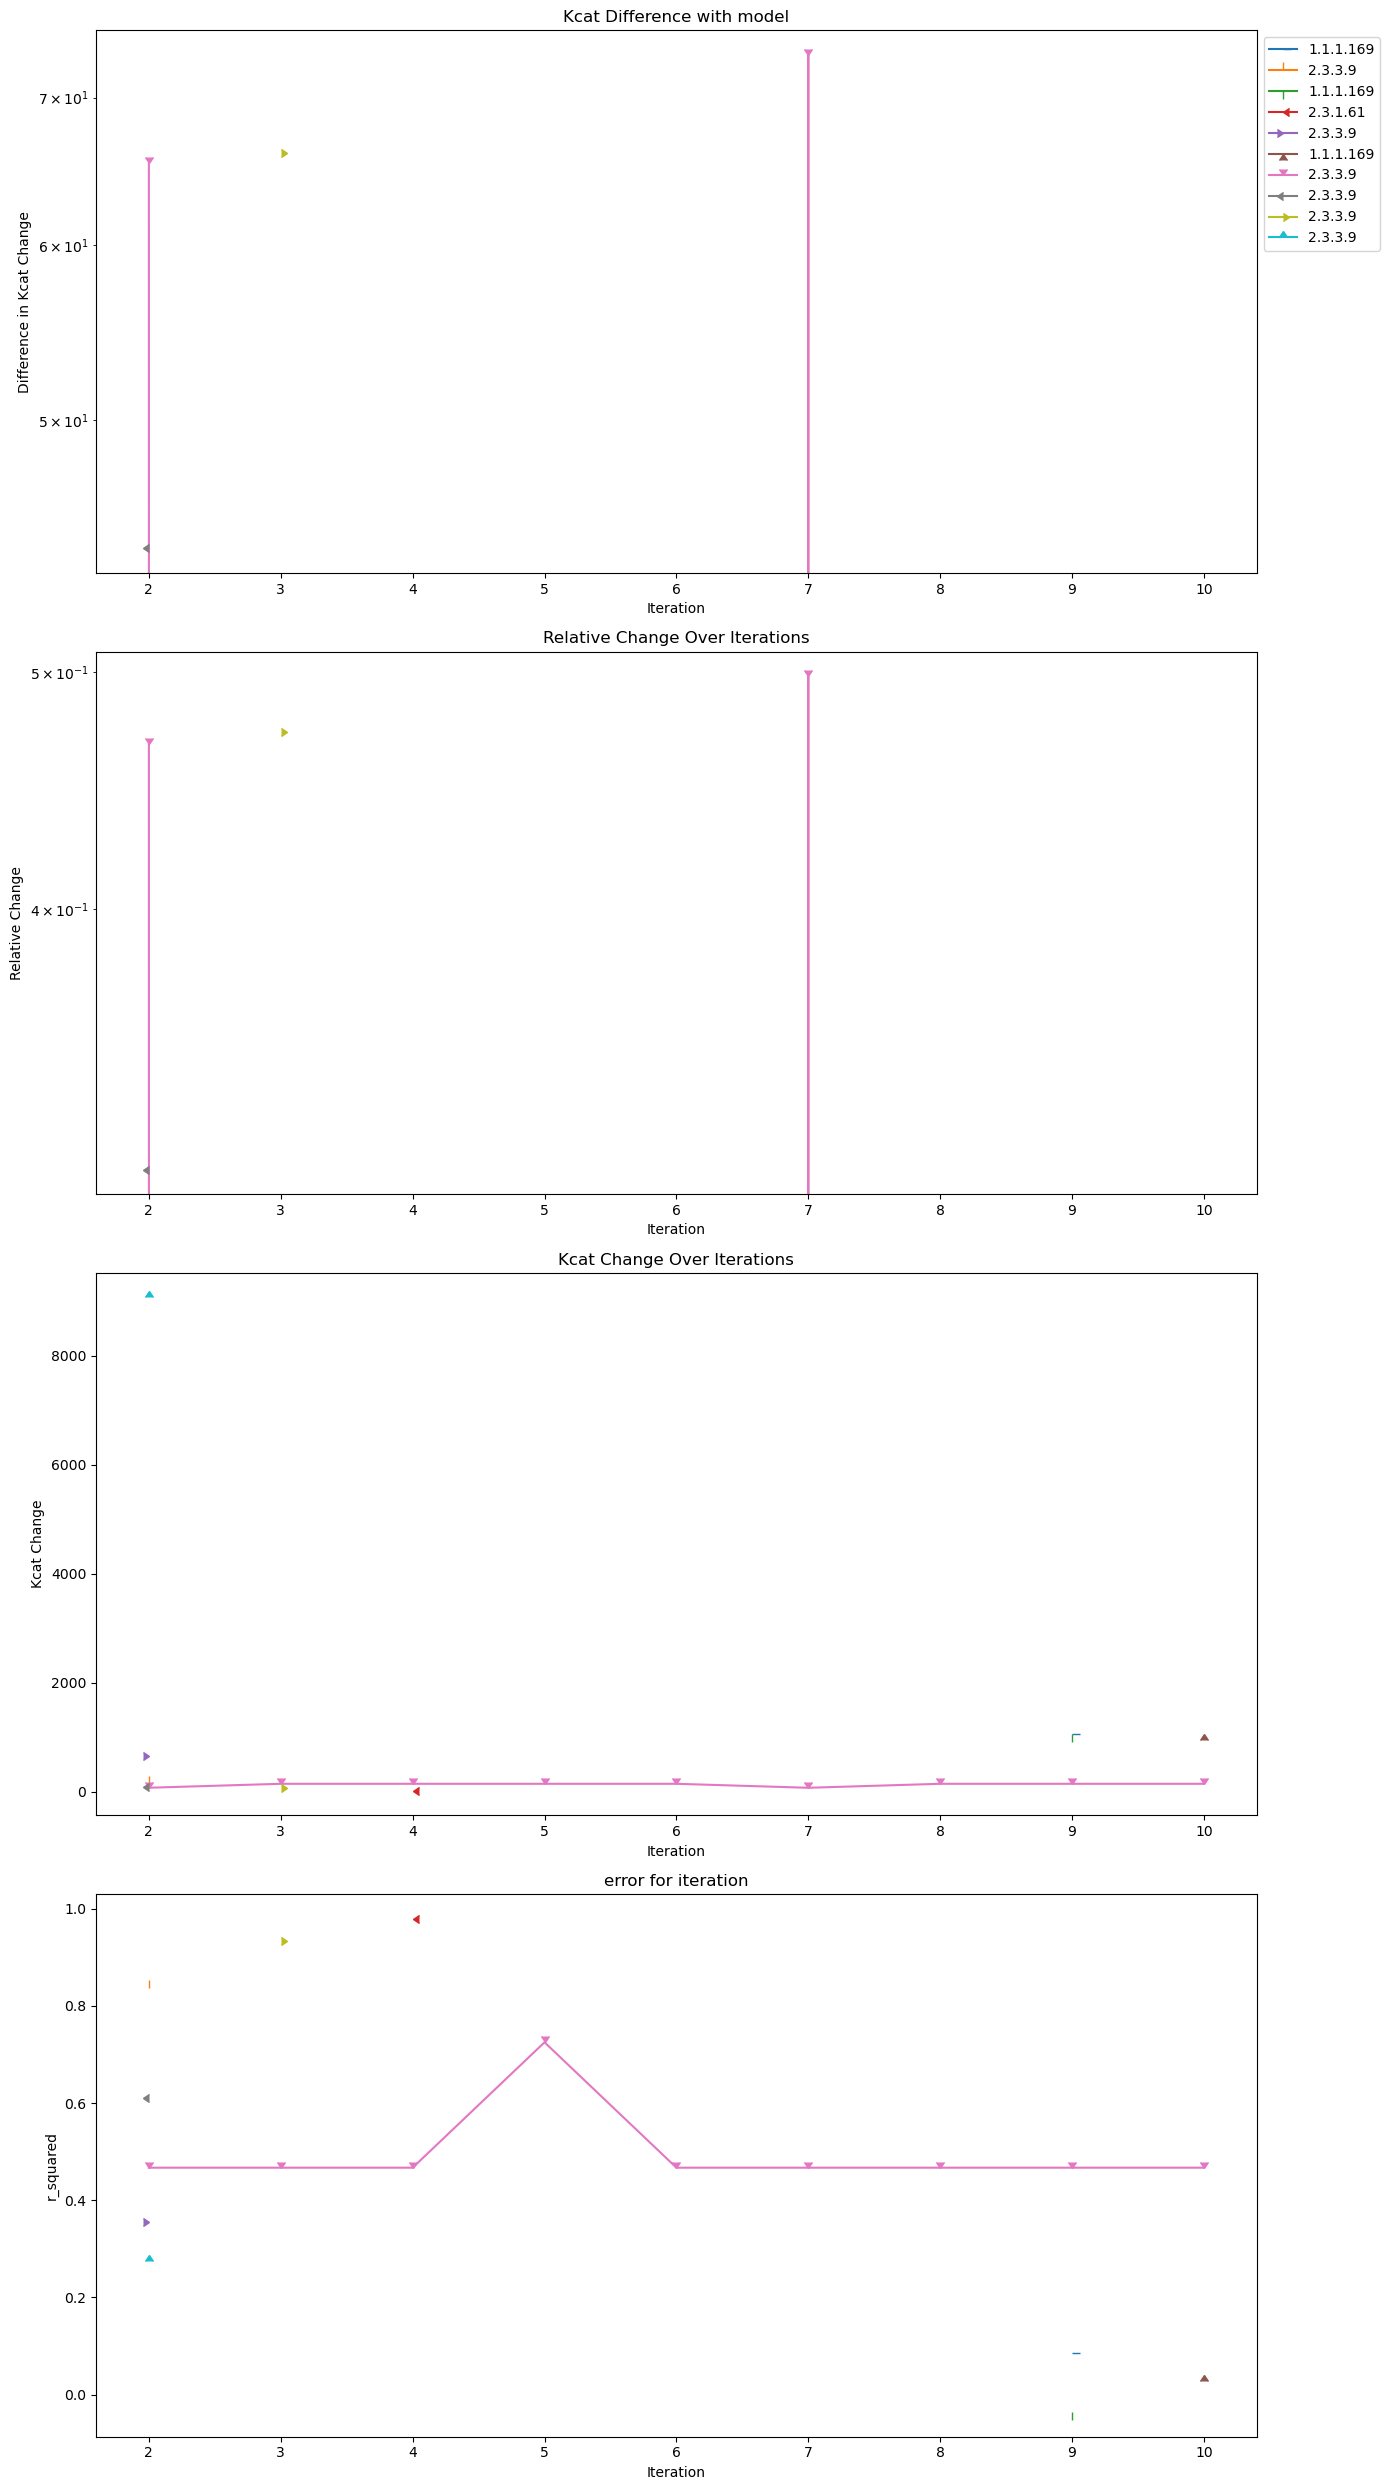

In [106]:
fig, axs = plt.subplots(4, 1, figsize=(14, 25), dpi=100)

# Line plot for kcat_change
for iteration, best_indiv_df in best_indiv_grouped:
    for enzyme_id, enzyme_data in best_indiv_df.groupby('enzyme_id'):
        axs[0].plot(enzyme_data['run_id'], enzyme_data['kcat_change'], marker=iteration, label=enzyme_id)
        axs[0].set_xlabel('Iteration')
        axs[0].set_ylabel('Difference in Kcat Change')
        axs[0].set_title('Kcat Difference with model')
        axs[0].legend(loc='upper left', bbox_to_anchor=(1, 1))

        # Line plot for relative_change
        axs[1].plot(enzyme_data['run_id'], enzyme_data['relative_change'], marker=iteration, label=enzyme_id)
        axs[1].set_xlabel('Iteration')
        axs[1].set_ylabel('Relative Change')
        axs[1].set_title('Relative Change Over Iterations')
    #     axs[1].legend(loc='upper left', bbox_to_anchor=(1, 1))

        axs[2].plot(enzyme_data['run_id'], enzyme_data['kcat[s-1]'], marker=iteration, label=enzyme_id)
        axs[2].set_xlabel('Iteration')
        axs[2].set_ylabel('Kcat Change')
        axs[2].set_title('Kcat Change Over Iterations')
    #     axs[2].legend(loc='upper left', bbox_to_anchor=(1, 1))
    
        axs[3].plot(enzyme_data['run_id'], enzyme_data['r_squared'], marker=iteration, label=enzyme_id)
        axs[3].set_xlabel('Iteration')
        axs[3].set_ylabel('r_squared')
        axs[3].set_title('error for iteration')
        break

axs[0].set_yscale('log')

axs[1].set_yscale('log')
plt.tight_layout()
plt.show()


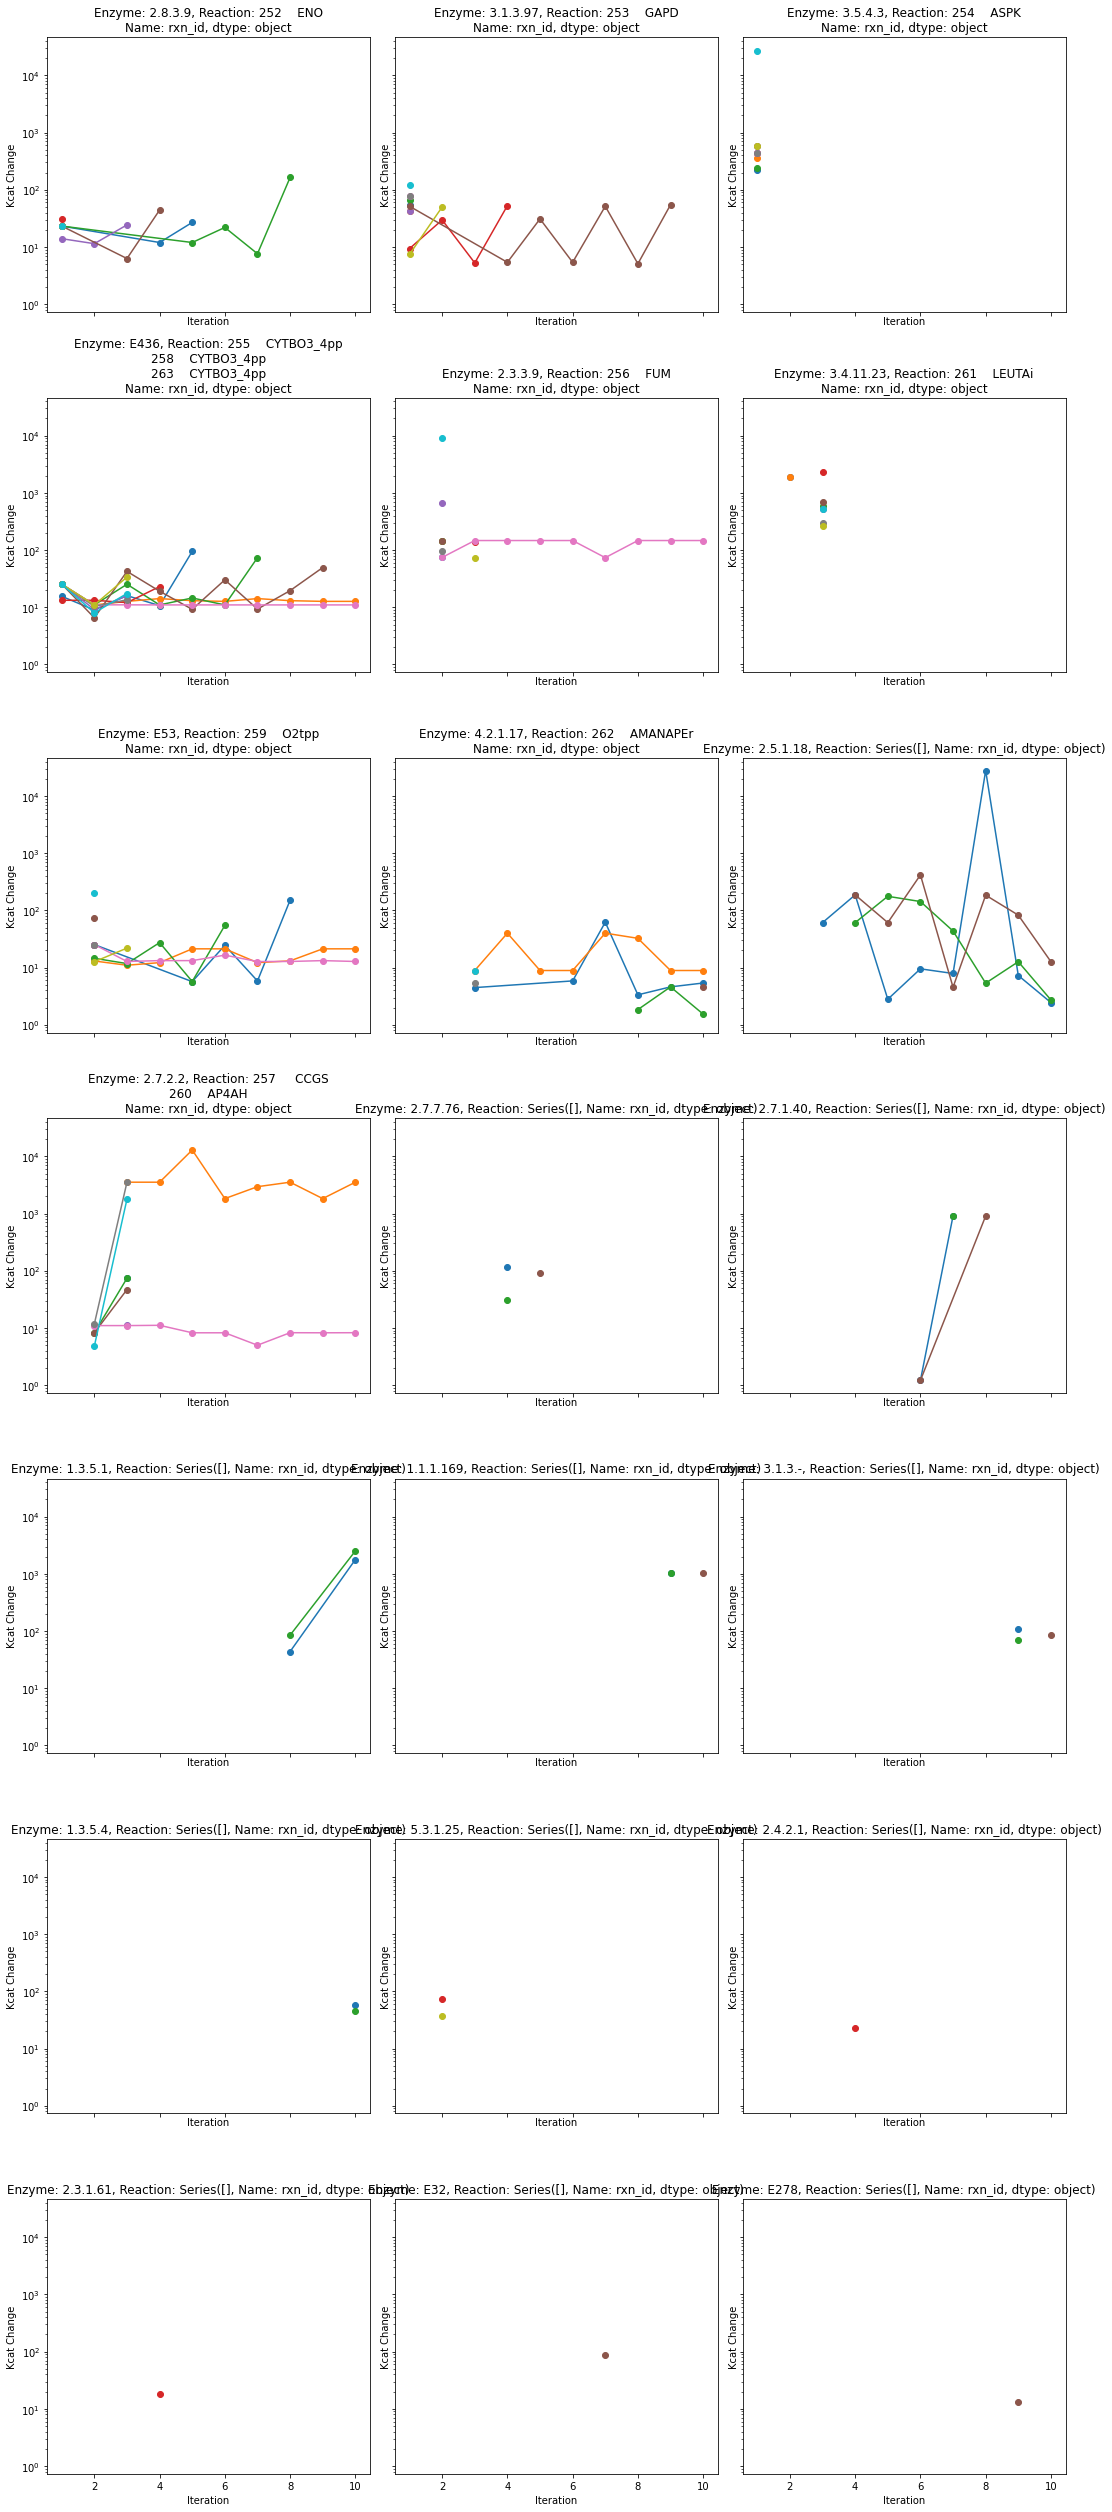

In [118]:
#per enzyme
# Set up the plot grid
n_rows = int(np.ceil(len(all_enzymes) / 3))
fig, axs = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows), sharex=True, sharey=True)
axs = axs.flatten()

# Plot each enzyme
for iteration, best_indiv_df in best_indiv_grouped:
    for i, enzyme in enumerate(all_enzymes):
        enzyme_data = best_indiv_df[best_indiv_df['enzyme_id'] == enzyme]
        axs[i].plot(enzyme_data['run_id'], enzyme_data['kcat[s-1]'], marker='o')
        axs[i].set_title(f'Enzyme: {enzyme}, Reaction: {enzyme_data["rxn_id"]}')
        axs[i].set_xlabel('Iteration')
        axs[i].set_ylabel('Kcat Change')
        axs[i].set_yscale('log')

# Remove any unused subplots
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

### 3.3 Heatmap

/tmp/ipykernel_8292/1847535100.py:4: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  heatmap_data = best_indiv_all_rounds_diff_kcat.pivot(["iteration", 'run_id'], "rxn_id", "kcat_change")


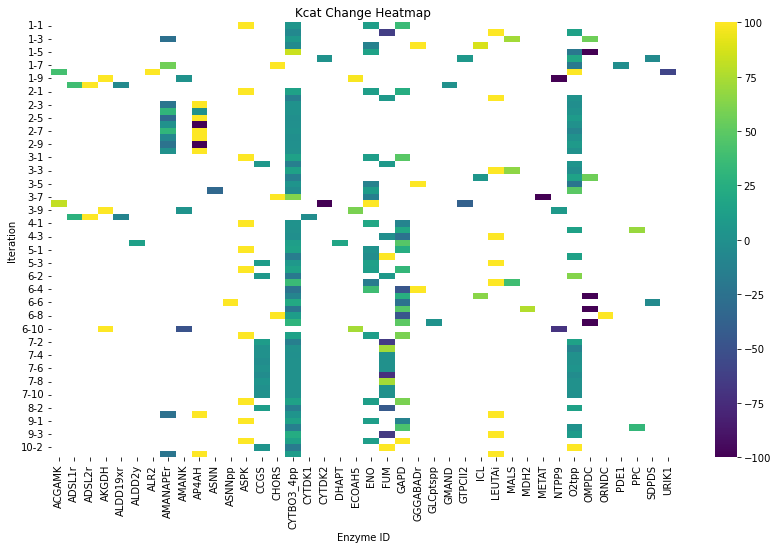

In [110]:
import seaborn as sns
from matplotlib.colors import LogNorm
# Pivot the dataframe for heatmap plotting
heatmap_data = best_indiv_all_rounds_diff_kcat.pivot(["iteration", 'run_id'], "rxn_id", "kcat_change")
# heatmap_data = heatmap_data.replace(0, np.nan)
# heatmap_data = heatmap_data.fillna(1e-6)

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, cmap="viridis",vmin = -100, vmax = 100)
plt.title('Kcat Change Heatmap')
plt.xlabel('Enzyme ID')
plt.ylabel('Iteration')
plt.show()

### 3.4 Bargraph

/tmp/ipykernel_8292/2909526917.py:4: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for run_id, best_indiv in best_indiv_all_rounds_diff_kcat.groupby(['run_id']):


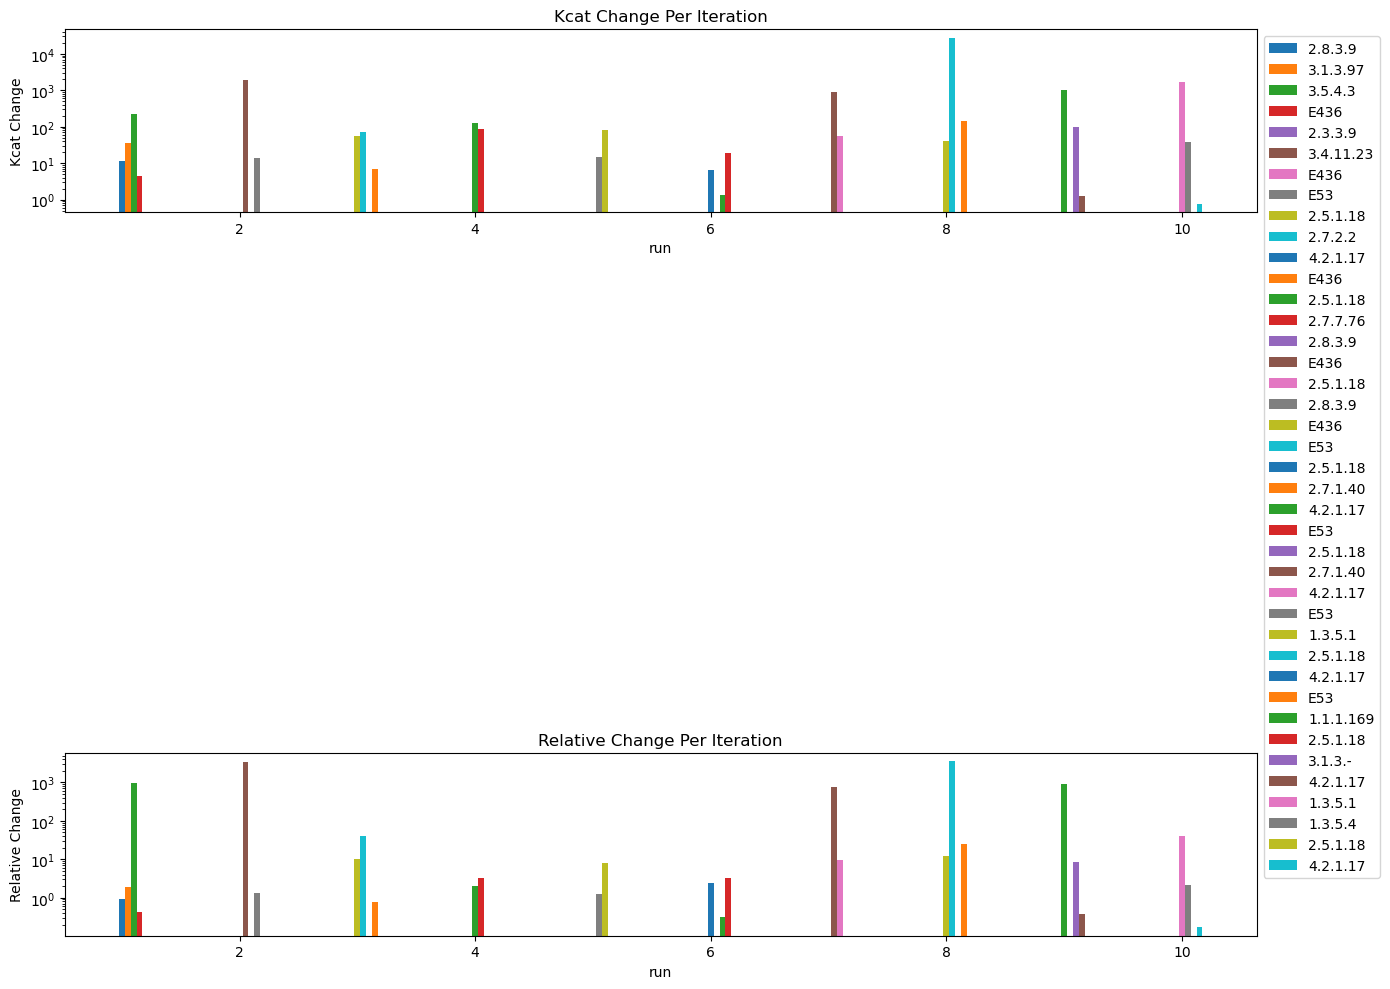

In [105]:
fig, axs = plt.subplots(2, 1, figsize=(14, 10), dpi=100)

# Bar plot for kcat_change
for run_id, best_indiv in best_indiv_all_rounds_diff_kcat.groupby(['run_id']):
    multiplier = 0
    width = 0.05
    for iteration, best_indiv_df in best_indiv.groupby('iteration'):
        for enzyme_id, enzyme_data in best_indiv_df.groupby('enzyme_id'):
            axs[0].bar(enzyme_data['run_id']+width*multiplier, enzyme_data['kcat_change'], width = width, label=enzyme_id)
            axs[0].set_xlabel('run')
            axs[0].set_ylabel('Kcat Change')
            axs[0].set_title('Kcat Change Per Iteration')
            axs[0].legend(loc='upper left', bbox_to_anchor=(1, 1))
            axs[0].set_yscale('log')

            axs[1].bar(enzyme_data['run_id']+width*multiplier, enzyme_data['relative_change'], width = width, label=enzyme_id)
            axs[1].set_xlabel('run')
            axs[1].set_ylabel('Relative Change')
            axs[1].set_title('Relative Change Per Iteration')
    #         axs[1].legend(loc='upper left', bbox_to_anchor=(1, 1))
            axs[1].set_yscale('log')
            multiplier += 1
        break
        
plt.tight_layout()
plt.show()


## 4. Study changes of all enzymes after parametrization
### 4.1 Get all changed enzymes

In [220]:
#only keep the datapoints until max rsuared is reached
max_r_squared_data = pd.DataFrame()
grouped = best_indiv_all_rounds.groupby('iteration')
for name, group in grouped:
    max_r_squared_row = group.loc[group['r_squared'].idxmax()]
    max_run_id = max_r_squared_row['run_id']
        
    subset = group[group['run_id'] <= max_run_id]
    max_r_squared_data = pd.concat([max_r_squared_data, subset])

max_r_squared_data

,index,iteration,binned,run_id,enzyme_id,rxn_id,kcat[s-1],ga_error,r_squared,direction
0,0,1,False,1,2.8.3.9,ENO,23.208296,0.256433,0.130208,f
1,1,1,False,1,3.1.3.97,GAPD,54.046449,0.256433,0.130208,f
2,2,1,False,1,3.5.4.3,ASPK,223.850395,0.256433,0.130208,f
3,3,1,False,1,E436,CYTBO3_4pp,15.554025,0.256433,0.130208,f
4,4,1,False,2,2.3.3.9,FUM,75.915203,0.305979,0.815029,f
...,...,...,...,...,...,...,...,...,...,...
522,1073,10,False,3,2.7.2.2,AP4AH,1784.557952,-1.025389,0.990475,f
523,1083,10,False,3,3.4.11.23,LEUTAi,512.599701,-1.025389,0.990475,f
524,1092,10,False,3,4.2.1.17,AMANAPEr,8.896490,-1.025389,0.983968,f
525,1093,10,False,3,4.2.1.17,AMANAPEr,8.896490,-1.025389,0.990475,f


In [221]:
best_indiv_all_rounds_last_value = max_r_squared_data.drop_duplicates(['enzyme_id','rxn_id', 'iteration'], keep = 'last')
best_kcats_differences = best_indiv_all_rounds_last_value.groupby(
    'iteration').apply(calculate_kcat_differences).reset_index(drop=True)
best_kcats_differences

,index,iteration,binned,run_id,enzyme_id,rxn_id,kcat[s-1],ga_error,r_squared,direction,previous_kcat,kcat_change,relative_change
0,1,1,False,1,3.1.3.97,GAPD,54.046449,0.256433,0.130208,f,18.781900,35.264549,1.877582
1,2,1,False,1,3.5.4.3,ASPK,223.850395,0.256433,0.130208,f,0.232600,223.617795,961.383471
2,4,1,False,2,2.3.3.9,FUM,75.915203,0.305979,0.815029,f,139.841200,-63.925997,-0.457133
3,5,1,False,2,3.4.11.23,LEUTAi,1873.214632,0.305979,0.815029,f,0.561400,1872.653232,3335.684418
4,7,1,False,2,E53,O2tpp,25.252525,0.305979,0.815029,f,11.000000,14.252525,1.295684
...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,1063,10,False,2,E53,O2tpp,204.165543,0.377260,0.598890,f,11.000000,193.165543,17.560504
91,1073,10,False,3,2.7.2.2,AP4AH,1784.557952,-1.025389,0.990475,f,4.820217,1779.737734,369.223550
92,1083,10,False,3,3.4.11.23,LEUTAi,512.599701,-1.025389,0.990475,f,0.561400,512.038301,912.073923
93,1093,10,False,3,4.2.1.17,AMANAPEr,8.896490,-1.025389,0.990475,f,31.223300,-22.326810,-0.715069


### 4.2 plots

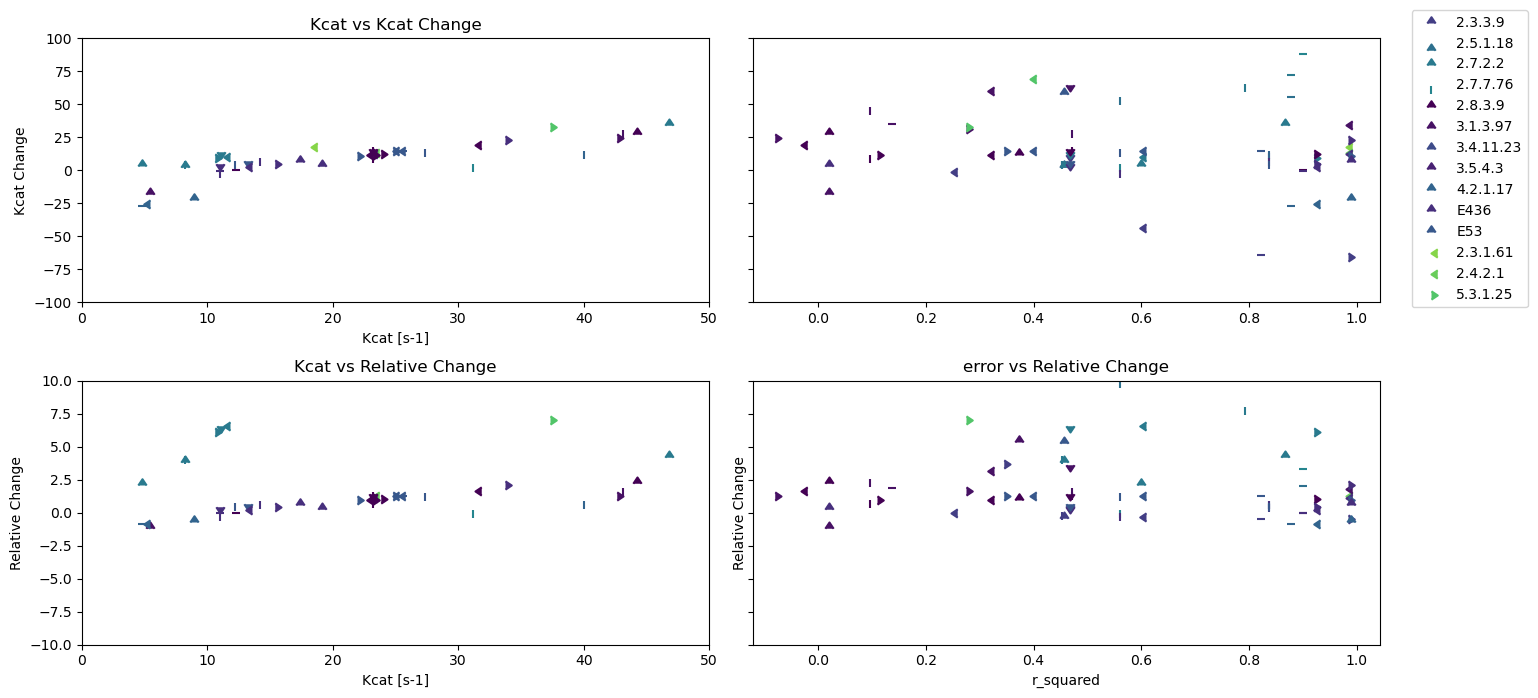

In [222]:
config = best_kcats_differences.iloc[0]['binned']

fig, axs = plt.subplots(ncols=len(result_file_names)+1,nrows = 2, sharey='row',figsize=(14, 7), dpi=100)
for iteration, best_indiv_df in best_kcats_differences.groupby('iteration'):
    row_index = 0
    for enzyme_id, enzyme_data in best_indiv_df.groupby('enzyme_id'):
        color = enzyme_to_color[enzyme_id]
        
        # Plot for kcat_change
        axs[row_index, 0].scatter(enzyme_data['kcat[s-1]'], enzyme_data['kcat_change'], 
                                  color=color, marker=iteration, label=f'{enzyme_id}')
        axs[row_index, 1].scatter(enzyme_data['r_squared'], enzyme_data['kcat_change'], 
                                  color=color, marker=iteration, label=f'{enzyme_id}')
        
        # Plot for relative_change
        axs[row_index + 1, 0].scatter(enzyme_data['kcat[s-1]'], enzyme_data['relative_change'], 
                                      color=color, marker=iteration, label=f'{enzyme_id}')
        
        # Plot for relative_change
        axs[row_index + 1, 1].scatter(enzyme_data['r_squared'], enzyme_data['relative_change'], 
                                      color=color, marker=iteration, label=f'{enzyme_id}')

# Set titles and labels
axs[0, 0].set_title('Kcat vs Kcat Change')
axs[0, 0].set_xlabel('Kcat [s-1]')
axs[0, 0].set_ylabel('Kcat Change')
axs[0, 0].set_ylim([-100,100])
axs[0, 0].set_xlim([0,50])

axs[1, 0].set_title('Kcat vs Relative Change')
axs[1, 0].set_xlabel('Kcat [s-1]')
axs[1, 0].set_ylabel('Relative Change')
axs[1, 1].set_title('error vs Relative Change')
axs[1, 1].set_xlabel('r_squared')
axs[1, 1].set_ylabel('Relative Change')

axs[1, 0].set_ylim([-10,10])
axs[1, 0].set_xlim([0,50])

# Create legends
handles, labels = axs[1, 0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(), loc='upper right', bbox_to_anchor=(1.1, 1))

plt.tight_layout()
plt.show()



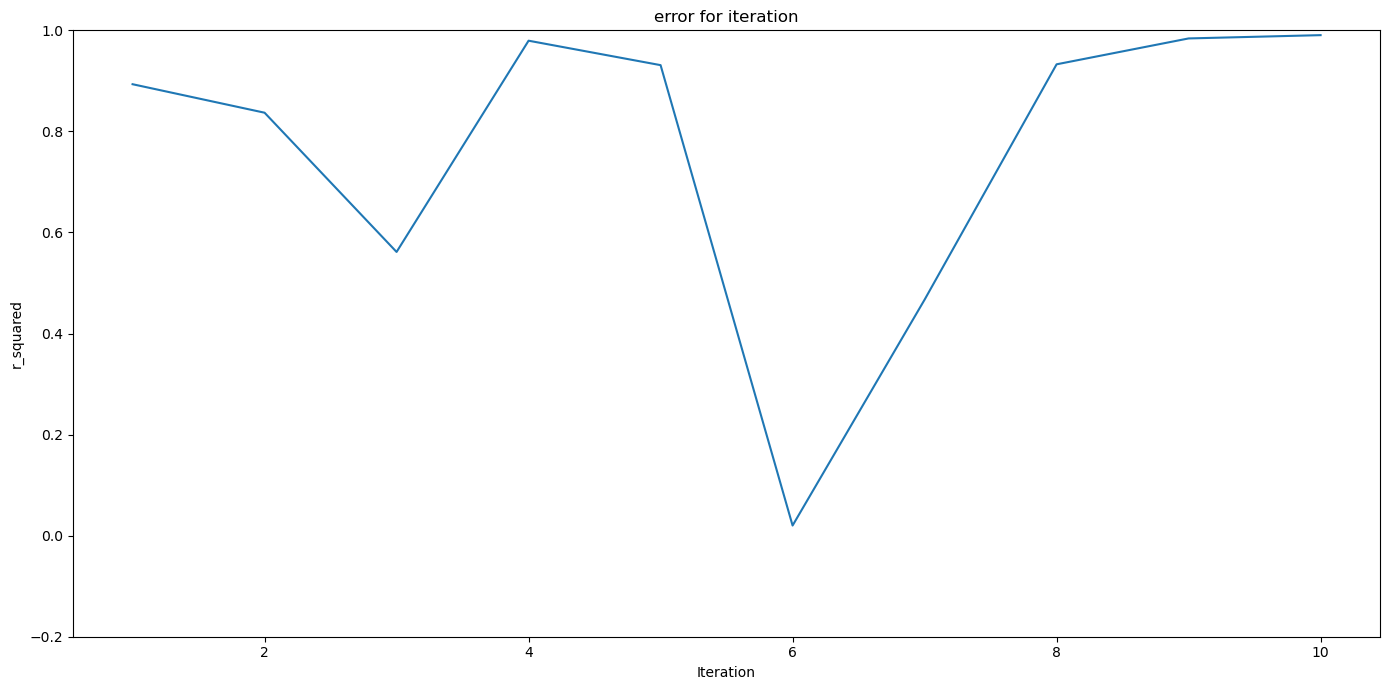

In [223]:
fig, axs = plt.subplots(1, 1, figsize=(14,7), dpi=100)
best_indiv_iteration_rsquared = best_kcats_differences.drop_duplicates(
    ['iteration'], keep = 'last').reset_index(drop=True)

# Line plot for error
axs.plot(best_indiv_iteration_rsquared['iteration'], best_indiv_iteration_rsquared['r_squared'])
axs.set_xlabel('Iteration')
axs.set_ylabel('r_squared')
axs.set_title('error for iteration')
axs.set_ylim(-0.2, 1)

plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

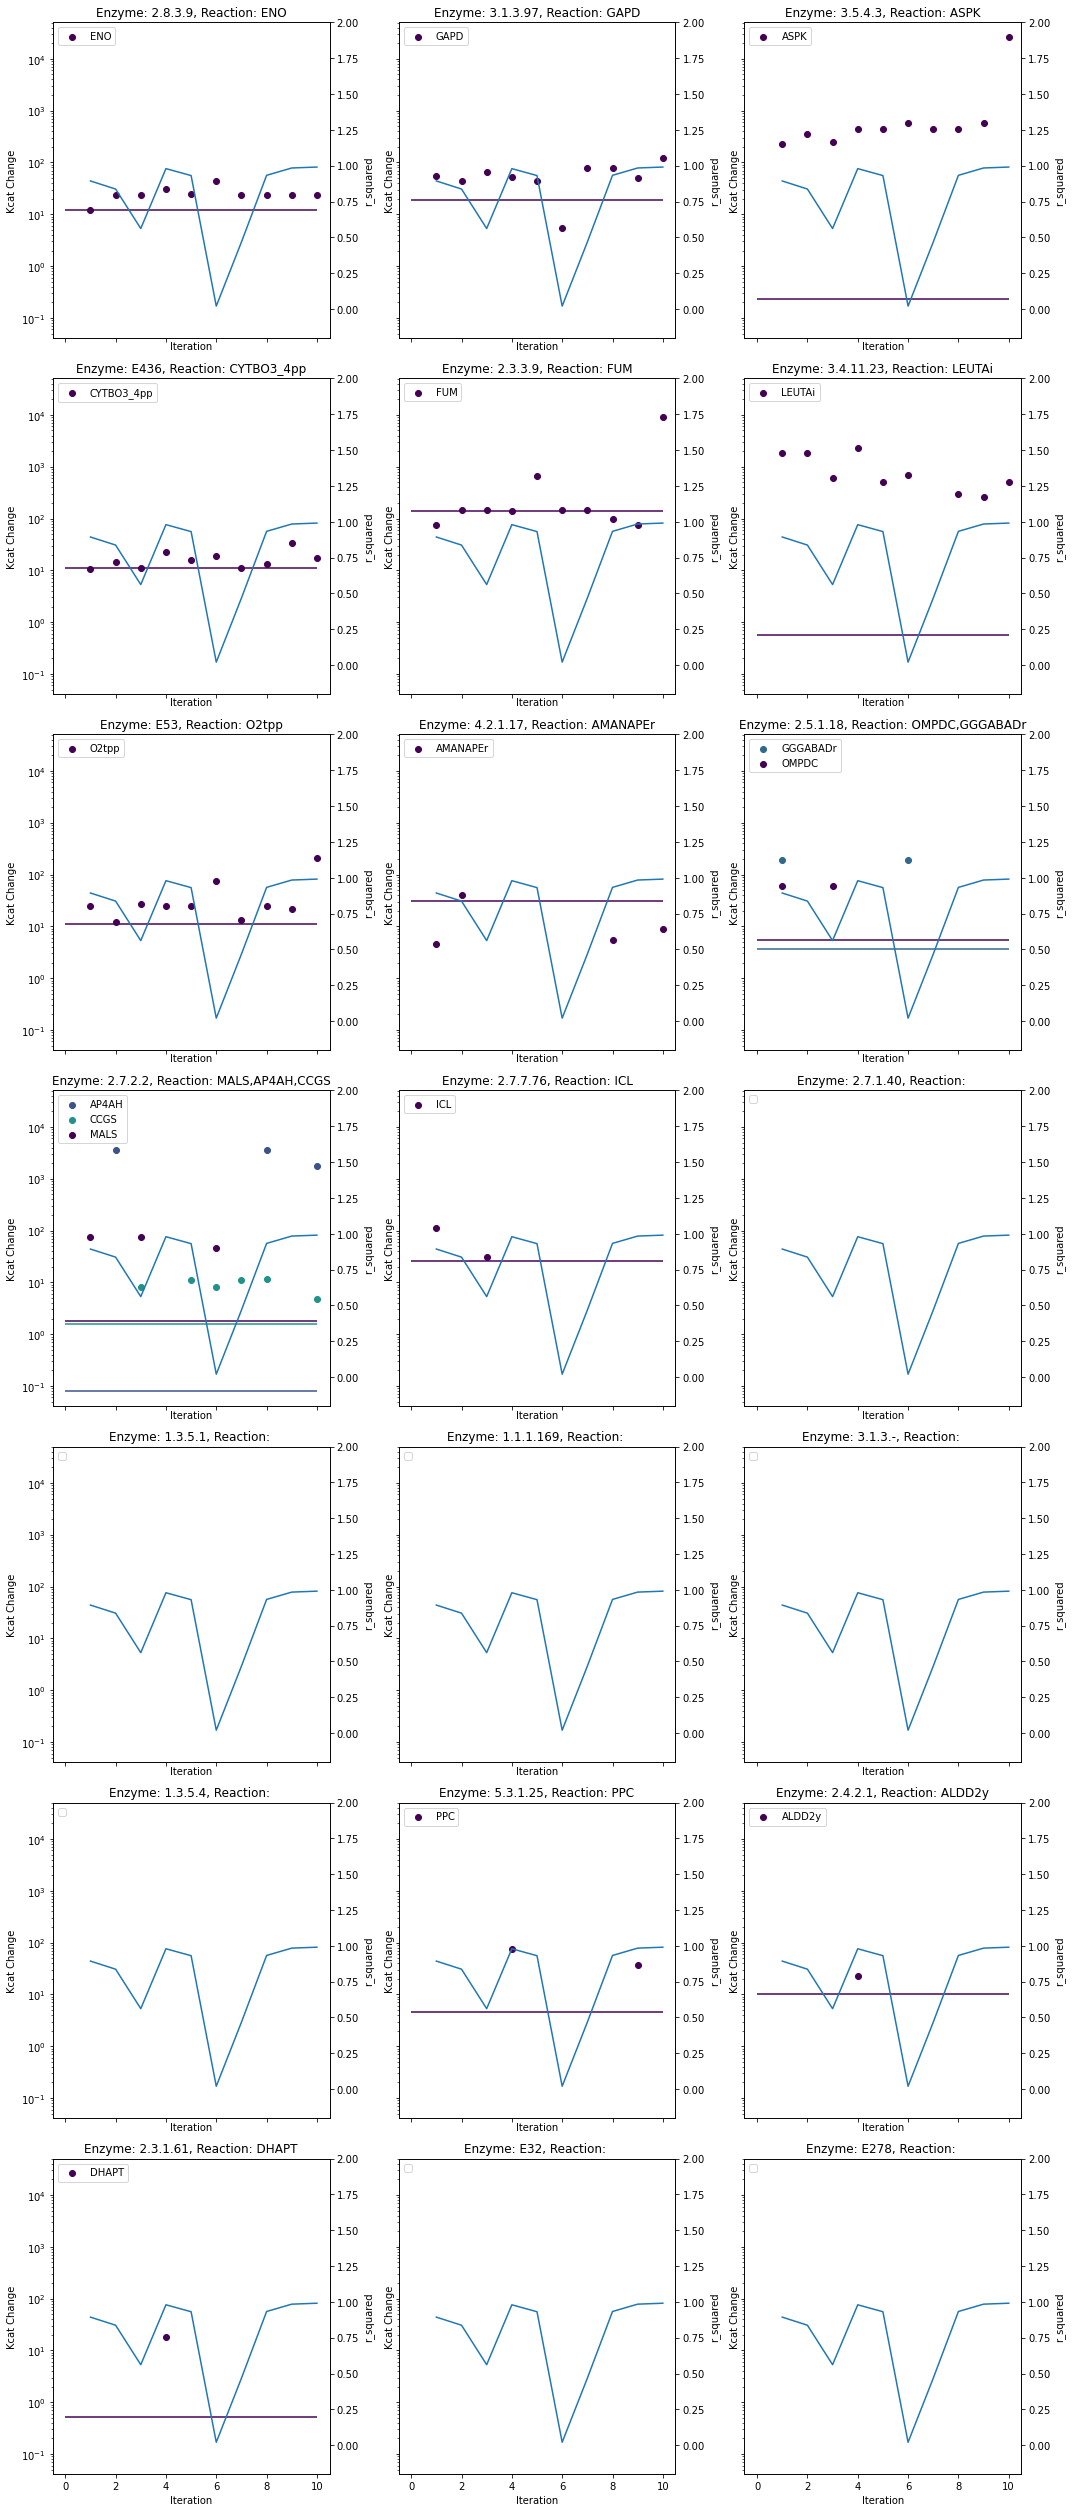

In [224]:
#per enzyme

# Set up the plot grid
n_rows = int(np.ceil(len(all_enzymes) / 3))
fig, axs = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows), sharex=True, sharey=True)
axs = axs.flatten()

# Plot each enzyme
for i, enzyme in enumerate(all_enzymes):
    enzyme_data = best_kcats_differences[best_kcats_differences['enzyme_id'] == enzyme]
    rxns = enzyme_data.rxn_id.unique()
    rxn_to_color = {rxn:to_hex(cmap(i / (len(rxns) + 1))) for i, rxn in enumerate(rxns)}
    for rxn, data in enzyme_data.groupby('rxn_id'):
        axs[i].scatter(data['iteration'], data['kcat[s-1]'], marker='o', color = rxn_to_color[rxn], label=rxn)
    
    #create reference line for original value
        if enzyme[0] != 'E':
            enzyme_kcat = original_kcat_df[
                        (original_kcat_df['rxnID'] == rxn) & 
                        (original_kcat_df['EC_nmbr'] == enzyme)
                    ]['kcat'].values[0]
        else:
            enzyme_kcat = original_kcat_df[
                        (original_kcat_df['rxnID'] == rxn)
                    ]['kcat'].values[0]
        axs[i].hlines(y = enzyme_kcat, xmin = 0, xmax=10, color = rxn_to_color[rxn])
    
    axs[i].legend(loc='upper left')
    
    axs[i].set_title(f'Enzyme: {enzyme}, Reaction: {",".join(enzyme_data["rxn_id"].drop_duplicates().to_list())}')
    axs[i].set_xlabel('Iteration')
    axs[i].set_ylabel('Kcat Change')
    axs[i].set_yscale('log')
    ax2 = axs[i].twinx()
    ax2.plot(best_indiv_iteration_rsquared['iteration'], best_indiv_iteration_rsquared['r_squared'])
    ax2.set_ylabel('r_squared')
    ax2.set_ylim([-0.2, 2])
    

# Remove any unused subplots
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

/tmp/ipykernel_8292/669130541.py:2: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  heatmap_data = best_kcats_differences.pivot(["iteration"], "rxn_id", "kcat[s-1]")


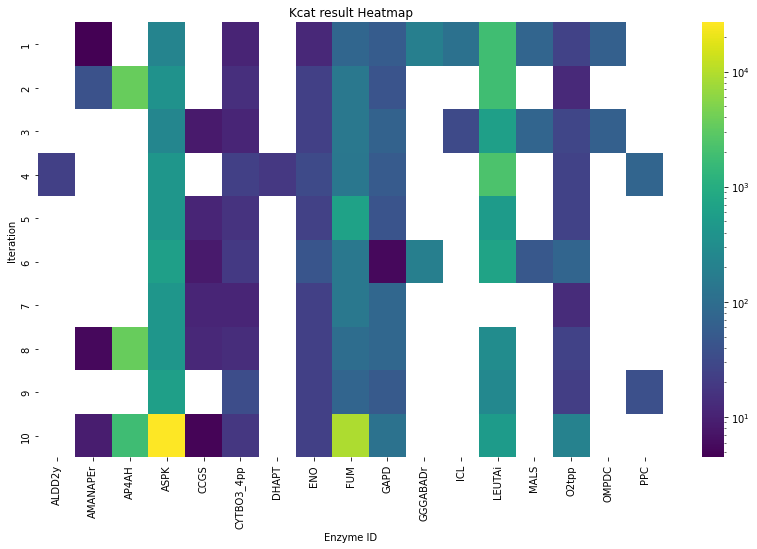

In [225]:
from matplotlib.colors import LogNorm
heatmap_data = best_kcats_differences.pivot(["iteration"], "rxn_id", "kcat[s-1]")
# heatmap_data = heatmap_data.replace(0, np.nan)
# heatmap_data = heatmap_data.fillna(1e-6)

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, cmap="viridis", norm = LogNorm())#,vmin = -100, vmax = 100)
plt.title('Kcat result Heatmap')
plt.xlabel('Enzyme ID')
plt.ylabel('Iteration')
plt.show()

### 5. Changes per pathway

In [226]:
# get pathway information from genelist file
gene_list_info = pd.read_excel(os.path.join('Data', 'GeneList_ecoli.xlsx'), sheet_name = 'GeneList')
rxn2gene_info = pd.read_excel(os.path.join('Data', 'GeneList_ecoli.xlsx'), sheet_name = 'gene2rxn')

In [227]:
# map cog information to reactions using the gene id
gene2rxns2cog = pd.merge(gene_list_info[['bnumber', 'COG description']], rxn2gene_info,
                       left_on = 'bnumber', right_on = 'Gene', how = 'inner')
gene2rxn2cog.Reactions = gene2rxns2cog.Reactions.str.split(', ')
gene2rxn2cog['COG description'] = gene2rxn2cog['COG description'].str.split(';')
gene2rxn2cog = gene2rxn2cog.explode('Reactions')
gene2rxn2cog = gene2rxn2cog.explode('COG description').reset_index(drop=True)

gene2rxn2cog

,bnumber,COG description,Gene,Reactions
0,b0002,Amino acid transport and metabolism,b0002,ASPK
1,b0002,Amino acid transport and metabolism,b0002,HSDy
2,b0002,Amino acid transport and metabolism,b0002,HSK
3,b0002,Amino acid transport and metabolism,b0002,HOSK
4,b0003,Amino acid transport and metabolism,b0003,THRS
...,...,...,...,...
8177,b4467,Energy production and conversion,b4467,NaN
8178,b4474,Carbohydrate transport and metabolism,b4474,NaN
8179,b4477,Carbohydrate transport and metabolism,b4477,NaN
8180,b4485,Carbohydrate transport and metabolism,b4485,NaN


In [228]:
# map cog information to changed enzymes using the reactions
best_kcats_with_cog = pd.merge(best_kcats_differences, gene2rxn2cog[['Reactions', 'COG description']],
                               left_on='rxn_id', right_on = 'Reactions', how='left')
best_kcats_with_cog = best_kcats_with_cog.drop_duplicates(
    ['rxn_id','enzyme_id', 'r_squared', 'COG description']).reset_index(drop=True)

best_kcats_with_cog

,index,iteration,binned,run_id,enzyme_id,rxn_id,kcat[s-1],ga_error,r_squared,direction,previous_kcat,kcat_change,relative_change,Reactions,COG description
0,1,1,False,1,3.1.3.97,GAPD,54.046449,0.256433,0.130208,f,18.781900,35.264549,1.877582,GAPD,Amino acid transport and metabolism
1,2,1,False,1,3.5.4.3,ASPK,223.850395,0.256433,0.130208,f,0.232600,223.617795,961.383471,ASPK,Amino acid transport and metabolism
2,2,1,False,1,3.5.4.3,ASPK,223.850395,0.256433,0.130208,f,0.232600,223.617795,961.383471,ASPK,Cell wall/membrane/envelope biogenesis
3,4,1,False,2,2.3.3.9,FUM,75.915203,0.305979,0.815029,f,139.841200,-63.925997,-0.457133,NaN,NaN
4,5,1,False,2,3.4.11.23,LEUTAi,1873.214632,0.305979,0.815029,f,0.561400,1872.653232,3335.684418,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,1073,10,False,3,2.7.2.2,AP4AH,1784.557952,-1.025389,0.990475,f,4.820217,1779.737734,369.223550,AP4AH,Nucleotide transport and metabolism
119,1083,10,False,3,3.4.11.23,LEUTAi,512.599701,-1.025389,0.990475,f,0.561400,512.038301,912.073923,NaN,NaN
120,1093,10,False,3,4.2.1.17,AMANAPEr,8.896490,-1.025389,0.990475,f,31.223300,-22.326810,-0.715069,AMANAPEr,"Posttranslational modification, protein turnov..."
121,1103,10,False,3,E436,CYTBO3_4pp,17.404820,-1.025389,0.990475,f,11.000000,6.404820,0.582256,CYTBO3_4pp,Inorganic ion transport and metabolism


In [229]:
# Calculate cumulative change of each COG category per iteration
best_kcats_change_per_cog = best_kcats_with_cog.groupby(['iteration', 'COG description'])['relative_change'].sum().reset_index()

# Calculate the absolute sum of relative changes per iteration
total_abs_change_per_iteration = best_kcats_with_cog.groupby('iteration')['relative_change'].sum().abs().reset_index()
total_abs_change_per_iteration.rename(columns={'relative_change': 'total_abs_change'}, inplace=True)

# Merge the cumulative changes with the total absolute changes
best_kcats_change_per_cog = pd.merge(best_kcats_change_per_cog, total_abs_change_per_iteration, on='iteration')

# Normalize the cumulative changes by the total absolute changes within each iteration
best_kcats_change_per_cog['normalized_relative_change'] = merged_df['relative_change'] / merged_df['total_abs_change']

best_kcats_change_per_cog

,iteration,COG description,relative_change,total_abs_change,normalized_relative_change
0,1,Amino acid transport and metabolism,963.261052,5354.247181,0.101952
1,1,Carbohydrate transport and metabolism,0.000000,5354.247181,0.001519
2,1,Cell wall/membrane/envelope biogenesis,1016.107342,5354.247181,0.000010
3,1,Coenzyme transport and metabolism,-0.027451,5354.247181,0.211143
4,1,Inorganic ion transport and metabolism,-0.027451,5354.247181,0.057160
...,...,...,...,...,...
58,10,Cell wall/membrane/envelope biogenesis,114930.120921,231231.772717,NaN
59,10,Coenzyme transport and metabolism,2.669171,231231.772717,NaN
60,10,Inorganic ion transport and metabolism,0.582256,231231.772717,NaN
61,10,Nucleotide transport and metabolism,369.223550,231231.772717,NaN


In [230]:
# plot the relative changes
cog_descriptions = best_kcats_change_per_cog['COG description'].drop_duplicates().to_list()
cog2rxns = {}
for i, row in best_kcats_with_cog[['Reactions', 'COG description']].iterrows():
    cog = row['COG description']
    if cog in cog2rxns.keys():
        cog2rxns[cog] += [row.Reactions]
    else:
        cog2rxns[cog] = [row.Reactions]

In [231]:
counts_per_cog_iteration = best_kcats_with_cog.groupby(['COG description', 'iteration']).index.count()


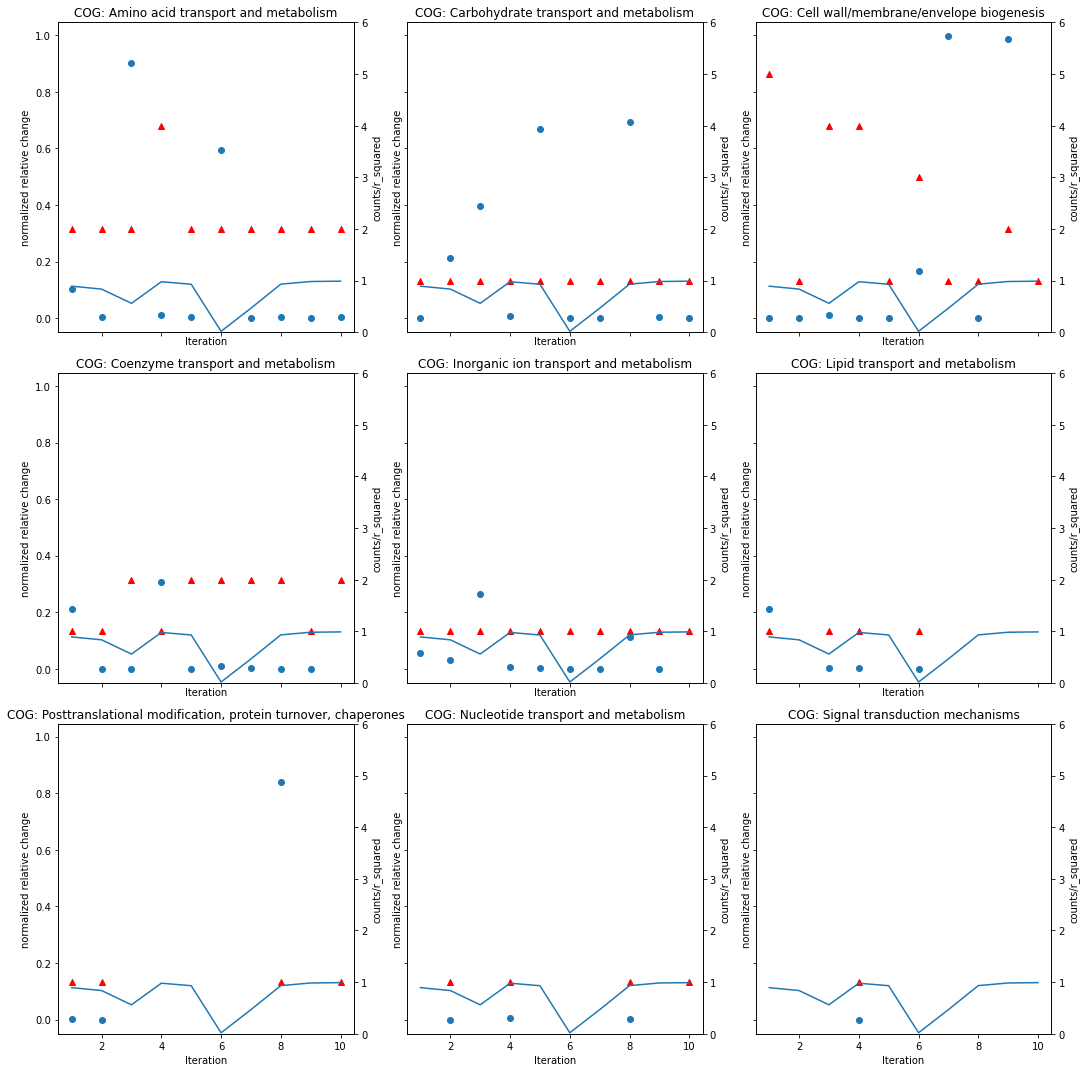

In [233]:
# Set up the plot grid
n_rows = int(np.ceil(len(cog_descriptions) / 3))
fig, axs = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows), sharex=True, sharey=True)
axs = axs.flatten()

# Plot each enzyme
for i, cog in enumerate(cog_descriptions):
    cog_data = best_kcats_change_per_cog[best_kcats_change_per_cog['COG description'] == cog]
    axs[i].scatter(cog_data['iteration'], cog_data['normalized_relative_change'], marker='o')
    
    #create reference line for original value
    axs[i].set_title(f'COG: {cog}')#, Reactions: {",".join(cog2rxns[cog])}')
    axs[i].set_xlabel('Iteration')
    axs[i].set_ylabel('normalized relative change')
#     axs[i].set_yscale('log')
    ax2 = axs[i].twinx()
    cog_counts = counts_per_cog_iteration.loc[cog]
    ax2.scatter(cog_counts.index, cog_counts.values, marker = '^', color = 'red')
    ax2.set_ylabel('counts/r_squared')
    ax2.plot(best_indiv_iteration_rsquared['iteration'], best_indiv_iteration_rsquared['r_squared'])
    ax2.set_ylim([0, 6])
    

# Remove any unused subplots
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()